# Problem Solution Pipeline

## Data Preparation
We utilize DuckDB to interface directly with our processed relational database. This demonstrates how Python interacts with DuckDB to query structured data efficiently without loading the entire raw dataset into memory.

In [11]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to the persistent DuckDB database
con = duckdb.connect('faers_ml.duckdb')

# Load data into DuckDB from Parquet files
print("Loading data from Parquet files into DuckDB...")
con.execute("""
    -- Drop dependent tables first to avoid foreign key catalog errors
    DROP TABLE IF EXISTS reactions CASCADE;
    DROP TABLE IF EXISTS outcomes CASCADE;
    DROP TABLE IF EXISTS drugs CASCADE;
    DROP TABLE IF EXISTS patients CASCADE;
    DROP TABLE IF EXISTS reports CASCADE;

    CREATE TABLE reports AS SELECT * FROM 'data/parquet/faers_reports.parquet';
    CREATE TABLE patients AS SELECT * FROM 'data/parquet/faers_patients.parquet';
    CREATE TABLE drugs AS SELECT * FROM 'data/parquet/faers_drugs.parquet';
    CREATE TABLE outcomes AS SELECT * FROM 'data/parquet/faers_outcomes.parquet';
    CREATE TABLE reactions AS SELECT * FROM 'data/parquet/faers_reactions.parquet';
""")

print("Connected to DuckDB successfully.")
print(con.execute("SHOW TABLES").df())

Loading data from Parquet files into DuckDB...
Connected to DuckDB successfully.
        name
0      drugs
1   outcomes
2   patients
3  reactions
4    reports


## Query: Preparing the Solution
Here we execute a Common Table Expression (CTE) query to join the reports, patients, drugs, and outcomes tables. This generates mathematically sound clinical proxies, such as polypharmacy burden, while extracting the severe_outcome target variable for modeling. This is also when the high-risk drug list is generated based on the background literature and is added as a feature to the modeling dataset.

In [12]:
# Define high-risk drugs used as clinical priors in feature engineering.
#See 03_feature_engineering.py for detailed rationale and literature sources behind this list.
HIGH_RISK_DRUGS = {
    # --- FAERS Volume Anchors (Sonawane 2018) ---
    'LENALIDOMIDE',   # Only drug in top 10 across all 3 outcome categories    # #3 disability outcomes; antidepressant class anchor
    'ACETAMINOPHEN',  # #5 death (7,664 reports)
    'METOCLOPRAMIDE', # #1 disability

    # --- Hospital ADR Admission Anchors (Pirmohamed 2004) ---
    'ASPIRIN',        # 218 cases; #1 drug in ADR admissions and deaths
    'WARFARIN',       # 129 cases; cross-study anticoagulant anchor
    'FUROSEMIDE',     # 128 cases; diuretic class anchor
    'DICLOFENAC',     # 52 cases; NSAID anchor (non-aspirin ADR profile)
    'DIGOXIN',        # 36 cases; narrow therapeutic index; toxicity admissions
    'IBUPROFEN',      # 34 cases; highest-volume OTC NSAID in US FAERS

    # --- Opioids (Post-2016 FAERS Death-Outcome Signal) ---
    'FENTANYL',       # Pirmohamed opiates group (5 cases); #1 opioid death signal
    'MORPHINE',       # Pirmohamed opiates group (20 cases)
    'TRAMADOL',       # Pirmohamed opiates group (8 cases)
    'OXYCODONE',      # US opioid crisis dominant FAERS death reporter
    'HYDROCODONE',    # US opioid crisis dominant FAERS death reporter
}

HIGH_RISK_PATTERN = '|'.join(sorted(HIGH_RISK_DRUGS))

# Execute the feature engineering query directly via DuckDB
query = f"""
WITH clean_patients AS (
    SELECT 
        report_id, 
        MAX(TRY_CAST(patient_age AS FLOAT)) AS patient_age, 
        MAX(patient_sex) AS patient_sex
    FROM patients
    WHERE patient_age IS NOT NULL AND patient_sex IS NOT NULL
      AND TRY_CAST(patient_age AS FLOAT) BETWEEN 0 AND 120
    GROUP BY report_id
    HAVING COUNT(DISTINCT patient_sex) = 1
),
drug_burden AS (
    SELECT 
        report_id,
        COUNT(DISTINCT drug_name) AS polypharmacy_count,
        SUM(CASE WHEN role_cod = 'PS' THEN 1 ELSE 0 END) AS primary_suspect_count,
        MAX(CASE 
            WHEN REGEXP_MATCHES(UPPER(COALESCE(drug_name, '')), '{HIGH_RISK_PATTERN}') 
            THEN 1 ELSE 0 
        END) AS is_high_risk_drug
    FROM drugs
    GROUP BY report_id
)
SELECT 
    r.report_id,
    r.reporter_type,
    c.patient_age,
    c.patient_sex,
    EXTRACT(YEAR FROM r.receive_date) AS report_year,
    COALESCE(d.polypharmacy_count, 0) AS polypharmacy_count,
    COALESCE(d.primary_suspect_count, 0) AS primary_suspect_count,
    COALESCE(d.is_high_risk_drug, 0) AS is_high_risk_drug,
    MAX(CASE WHEN o.outcome_code IN ('DE', 'LT', 'HO') THEN 1 ELSE 0 END) AS severe_outcome
FROM reports r
INNER JOIN clean_patients c ON r.report_id = c.report_id
LEFT JOIN drug_burden d ON r.report_id = d.report_id
LEFT JOIN outcomes o ON r.report_id = o.report_id
GROUP BY 
    r.report_id, c.patient_age, c.patient_sex, r.receive_date, r.reporter_type, 
    d.polypharmacy_count, d.primary_suspect_count, d.is_high_risk_drug;
"""

df = con.execute(query).fetchdf()

# Binarize sex (1 = Male, 0 = Female, -1 = Missing)
df['is_male'] = df['patient_sex'].map({'1': 1, 'M': 1, '2': 0, 'F': 0}).fillna(-1).astype('int8')

# Define the Master Feature Set (Explicitly excluding reporter_type to prevent confounding)
feature_cols = [
    'patient_age', 
    'is_male', 
    'polypharmacy_count', 
    'primary_suspect_count', 
    'is_high_risk_drug',
    'report_year',
    'reporter_type'
]

X = df[feature_cols]
y = df['severe_outcome']

print(f"Dataset ready: {len(df):,} records loaded from DuckDB.")

Dataset ready: 2,339,316 records loaded from DuckDB.


## Solution Analysis: Model Implementation
**Analysis Rationale:** The model’s objective is to predict rare, severe clinical outcomes by identifying non-linear risk thresholds based on a patient's demographic profile and polypharmacy burden. A Random Forest was selected because its decision-tree architecture naturally captures the compound risks of drug interactions without requiring manual mathematical transformations. To handle the scale of the dataset efficiently, we utilize bootstrap subsampling (`max_samples=0.2`), limiting each tree to a fraction of the data for faster training. To ensure clinical reliability against a dataset overwhelmingly biased toward non-serious reports, the design incorporates `stratify=y` for balanced train-test splits, `class_weight='balanced_subsample'` to adjust weights dynamically for each bootstrap sample, and `RandomizedSearchCV` optimized for `average_precision` to maximize the capture of true severe cases while minimizing false alarms.

In [13]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    average_precision_score, 
    roc_auc_score, 
    PrecisionRecallDisplay
)
import pandas as pd
import matplotlib.pyplot as plt

if len(X) > 500:
    # 1. Stratified Split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 2. Configure the Bootstrapped Forest
    # We use 'max_samples' to limit each tree to a fraction of the data.
    # This makes training significantly faster on 460k+ rows.
    rf_fast = RandomForestClassifier(
        bootstrap=True, 
        max_samples=0.2, # Each tree only sees 20% of the data (Bootstrap Subsampling)
        class_weight='balanced_subsample', # Weights updated per bootstrap
        random_state=42,
        n_jobs=-1
    )
    
    # 3. Randomized Search (Much faster than Grid Search)
    param_dist = {
        'n_estimators': [100, 200],
        'max_depth': [10, 15, 20],
        'min_samples_leaf': [2, 5, 10],
        'max_features': ['sqrt', 'log2']
    }
    
    search = RandomizedSearchCV(
        rf_fast, 
        param_distributions=param_dist, 
        n_iter=8, # Only 8 combinations to save time
        cv=3, 
        scoring='average_precision', 
        verbose=1
    )
    
    search.fit(X_train, y_train)
    best_rf = search.best_estimator_
    
    # 4. Predictions
    y_prob = best_rf.predict_proba(X_test)[:, 1]
    y_pred = best_rf.predict(X_test)
    
    print(f"--- 10-Year Universal Triage (Random Forest) ---")
    print(f"PR-AUC: {average_precision_score(y_test, y_prob):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # 5. Native Feature Importance
    # Random Forest allows us to see exactly which feature "split" the most danger.
    importances = pd.Series(
        best_rf.feature_importances_, index=X.columns
    ).sort_values(ascending=False)
    
    print("\nFeature Importance (Gini Impurity):")
    print(importances)

else:
    print("Insufficient data.")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
--- 10-Year Universal Triage (Random Forest) ---
PR-AUC: 0.5740

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.69      0.74    310791
           1       0.51      0.64      0.57    157073

    accuracy                           0.67    467864
   macro avg       0.65      0.67      0.65    467864
weighted avg       0.70      0.67      0.68    467864


Feature Importance (Gini Impurity):
polypharmacy_count       0.286425
reporter_type            0.203389
patient_age              0.202631
primary_suspect_count    0.099565
report_year              0.097763
is_high_risk_drug        0.063705
is_male                  0.046522
dtype: float64


## Visualize Results
**Visualization Rationale:** A Precision-Recall (PR) curve is utilized instead of a standard ROC curve due to the imbalanced nature of the clinical dataset. In datasets where severe events are rare, ROC curves can be misleading because the large volume of non-severe cases artificially inflates the model's apparent performance. By employing a PR curve and comparing it against the baseline incidence rate, we achieve a much more accurate representation of the model's ability to identify rare, severe events without triggering excessive false medical alarms.

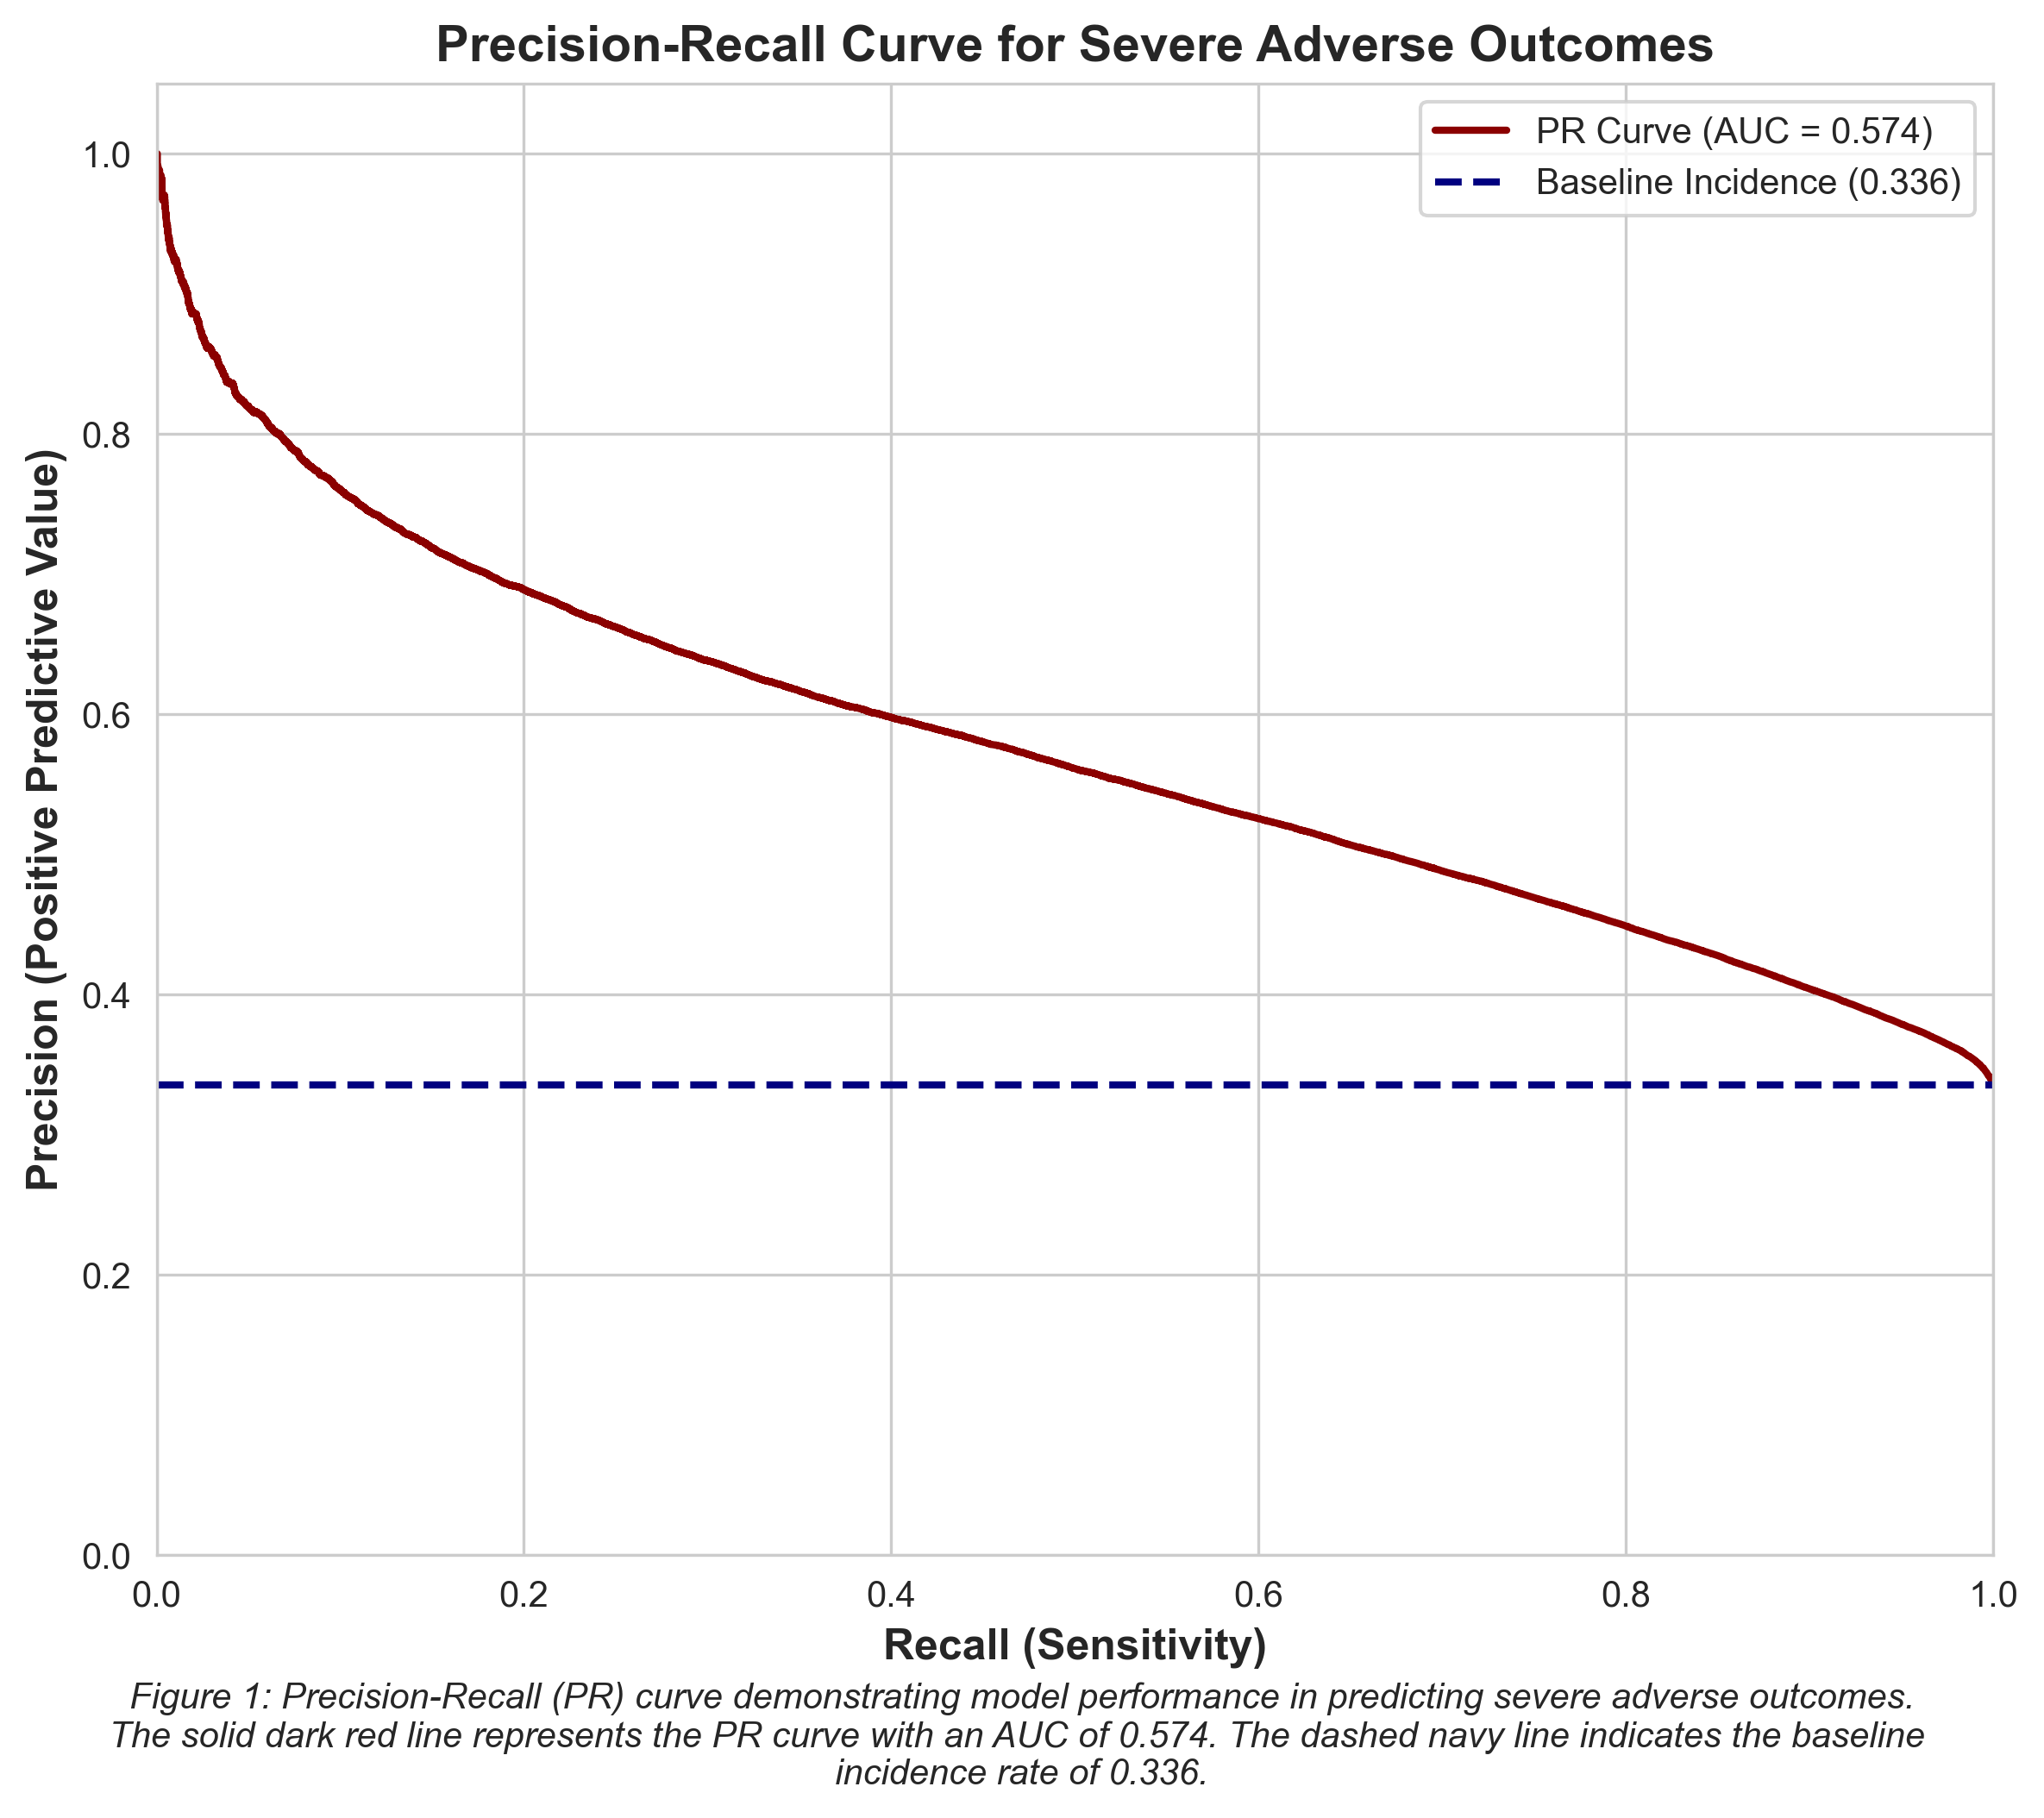

In [15]:
from sklearn.metrics import precision_recall_curve, auc


if len(X) > 100:
    # Compute precision-recall coordinates and baseline event prevalence.
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    baseline = y_test.sum() / len(y_test)

    # Create a high-resolution figure suitable for publication export.
    fig = plt.figure(figsize=(8, 7), dpi=300)
    sns.set_style("whitegrid")

    # Plot model performance against the baseline incidence rate.
    plt.plot(recall, precision, color='darkred', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
    plt.axhline(y=baseline, color='navy', lw=2, linestyle='--', label=f'Baseline Incidence ({baseline:.3f})')

    # Standardize axes and labels for interpretability.
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
    plt.ylabel('Precision (Positive Predictive Value)', fontsize=12, fontweight='bold')
    plt.title('Precision-Recall Curve for Severe Adverse Outcomes', fontsize=14, fontweight='bold')
    plt.legend(loc="upper right")

    # Add a concise caption summarizing key visual elements.
    caption = "Figure 1: Precision-Recall (PR) curve demonstrating model performance in predicting severe adverse outcomes.\n" \
              "The solid dark red line represents the PR curve with an AUC of {:.3f}. The dashed navy line indicates the baseline \n" \
              "incidence rate of {:.3f}.".format(pr_auc, baseline)
    plt.figtext(0.5, 0.01, caption, wrap=True, horizontalalignment='center', fontsize=10, style='italic')

    # Leave space for caption, then save and display.
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig('./images/pr_curve.png')
    plt.show()